In [5]:
!pip install numpy pandas matplotlib scikit-learn
!pip install torch torchvision torchaudio
!pip install seaborn jupyterlab

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
from sklearn.metrics import mean_squared_error

In [7]:
df = pd.read_csv("D:\Sema\StockPrice\AMZN_2006-01-01_to_2018-01-01.csv")
df.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,47.47,47.85,46.25,47.58,7582127,AMZN
1,2006-01-04,47.48,47.73,46.69,47.25,7440914,AMZN
2,2006-01-05,47.16,48.20,47.11,47.65,5417258,AMZN
3,2006-01-06,47.97,48.58,47.32,47.87,6154285,AMZN
4,2006-01-09,46.55,47.10,46.40,47.08,8945056,AMZN


In [8]:
scaler = MinMaxScaler(feature_range=(-1,1))
close_data = scaler.fit_transform(df['Close'].values.reshape(-1,1))

In [9]:
lookback = 20
X, y = [], []

for i in range(len(close_data) - lookback):
    X.append(close_data[i:i+lookback])
    y.append(close_data[i+lookback])

X = np.array(X)
y = np.array(y)

In [10]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [11]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out[:, -1, :])
        return out

model = LSTMModel()

In [13]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
print("done")

Epoch 1, Loss: 0.0004
Epoch 2, Loss: 0.0009
Epoch 3, Loss: 0.0002
Epoch 4, Loss: 0.0002
Epoch 5, Loss: 0.0004
Epoch 6, Loss: 0.0008
Epoch 7, Loss: 0.0004
Epoch 8, Loss: 0.0002
Epoch 9, Loss: 0.0004
Epoch 10, Loss: 0.0004
done


In [14]:
model.eval()
with torch.no_grad():
    predictions = model(X_tensor).numpy()

predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_tensor.numpy())

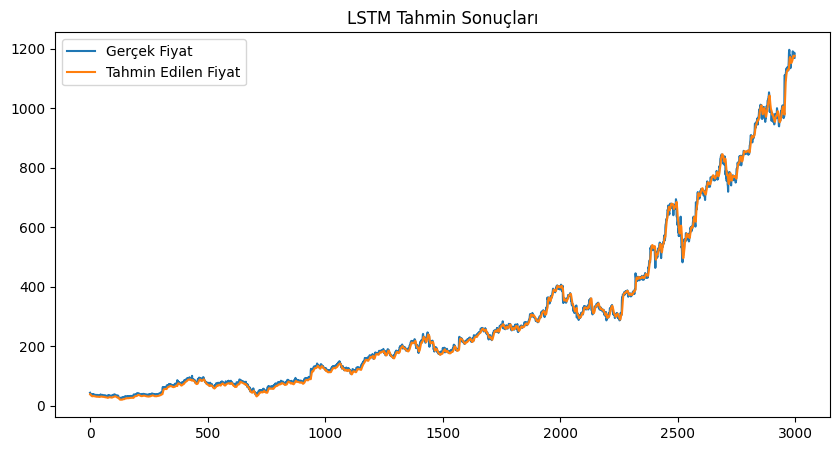

In [15]:
plt.figure(figsize=(10,5))
plt.plot(actual_prices, label="Gerçek Fiyat")
plt.plot(predicted_prices, label="Tahmin Edilen Fiyat")
plt.legend()
plt.title("LSTM Tahmin Sonuçları")
plt.show()

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, output_size=1):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out

In [17]:
gru_model = GRUModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(gru_model.parameters(), lr=0.001)

for epoch in range(10):
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = gru_model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")
print("done")

Epoch 1, Loss: 0.0011
Epoch 2, Loss: 0.0005
Epoch 3, Loss: 0.0005
Epoch 4, Loss: 0.0009
Epoch 5, Loss: 0.0002
Epoch 6, Loss: 0.0003
Epoch 7, Loss: 0.0009
Epoch 8, Loss: 0.0001
Epoch 9, Loss: 0.0003
Epoch 10, Loss: 0.0002
done


In [18]:
gru_model.eval()
with torch.no_grad():
    gru_predictions = gru_model(X_tensor).numpy()

gru_predicted_prices = scaler.inverse_transform(gru_predictions)

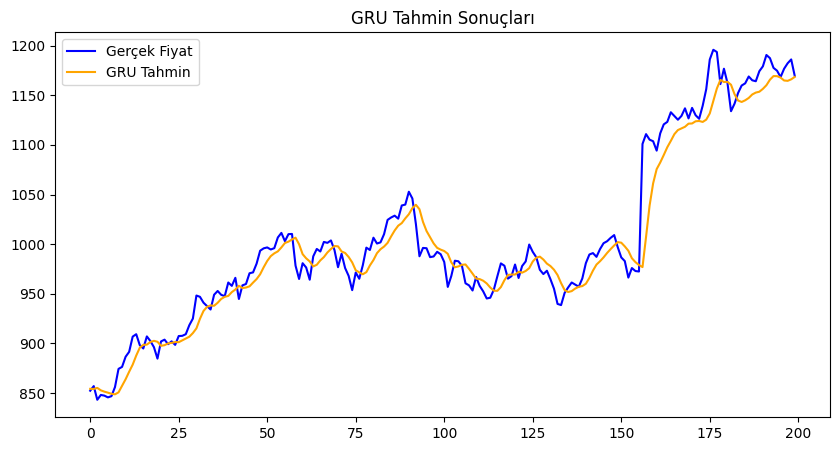

In [19]:
plt.figure(figsize=(10,5))
plt.plot(actual_prices[-200:], label="Gerçek Fiyat", color="blue")
plt.plot(gru_predicted_prices[-200:], label="GRU Tahmin", color="orange")
plt.legend()
plt.title("GRU Tahmin Sonuçları")
plt.show()

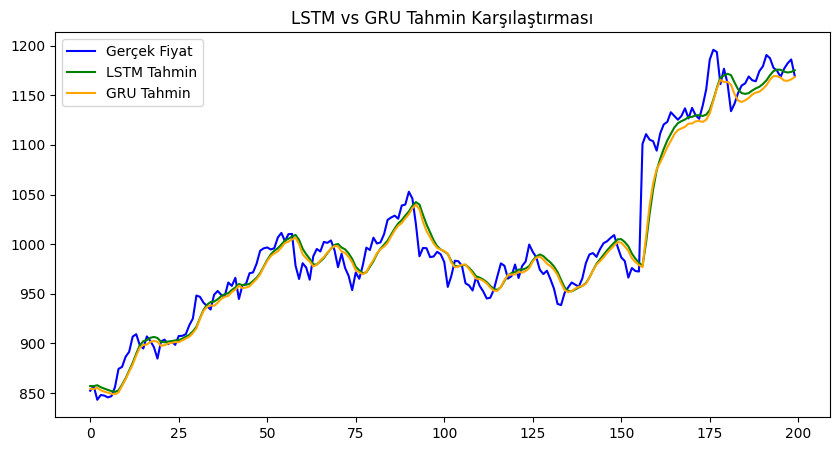

In [20]:
plt.figure(figsize=(10,5))
plt.plot(actual_prices[-200:], label="Gerçek Fiyat", color="blue")
plt.plot(predicted_prices[-200:], label="LSTM Tahmin", color="green")
plt.plot(gru_predicted_prices[-200:], label="GRU Tahmin", color="orange")
plt.legend()
plt.title("LSTM vs GRU Tahmin Karşılaştırması")
plt.show()

In [21]:
mse_lstm = mean_squared_error(actual_prices, predicted_prices)
mse_gru = mean_squared_error(actual_prices, gru_predicted_prices)

print("LSTM MSE:", mse_lstm)
print("GRU MSE:", mse_gru)

LSTM MSE: 110.41254425048828
GRU MSE: 97.82757568359375


In [22]:
num_epochs = 50
loss_values = []

for epoch in range(num_epochs):
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    loss_values.append(avg_loss)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")
print("done")

Epoch 1, Avg Loss: 0.0003
Epoch 2, Avg Loss: 0.0003
Epoch 3, Avg Loss: 0.0003
Epoch 4, Avg Loss: 0.0003
Epoch 5, Avg Loss: 0.0003
Epoch 6, Avg Loss: 0.0003
Epoch 7, Avg Loss: 0.0003
Epoch 8, Avg Loss: 0.0003
Epoch 9, Avg Loss: 0.0003
Epoch 10, Avg Loss: 0.0003
Epoch 11, Avg Loss: 0.0003
Epoch 12, Avg Loss: 0.0003
Epoch 13, Avg Loss: 0.0003
Epoch 14, Avg Loss: 0.0003
Epoch 15, Avg Loss: 0.0003
Epoch 16, Avg Loss: 0.0003
Epoch 17, Avg Loss: 0.0003
Epoch 18, Avg Loss: 0.0003
Epoch 19, Avg Loss: 0.0003
Epoch 20, Avg Loss: 0.0003
Epoch 21, Avg Loss: 0.0003
Epoch 22, Avg Loss: 0.0003
Epoch 23, Avg Loss: 0.0003
Epoch 24, Avg Loss: 0.0003
Epoch 25, Avg Loss: 0.0003
Epoch 26, Avg Loss: 0.0003
Epoch 27, Avg Loss: 0.0003
Epoch 28, Avg Loss: 0.0003
Epoch 29, Avg Loss: 0.0003
Epoch 30, Avg Loss: 0.0003
Epoch 31, Avg Loss: 0.0003
Epoch 32, Avg Loss: 0.0003
Epoch 33, Avg Loss: 0.0003
Epoch 34, Avg Loss: 0.0003
Epoch 35, Avg Loss: 0.0003
Epoch 36, Avg Loss: 0.0003
Epoch 37, Avg Loss: 0.0003
Epoch 38, 

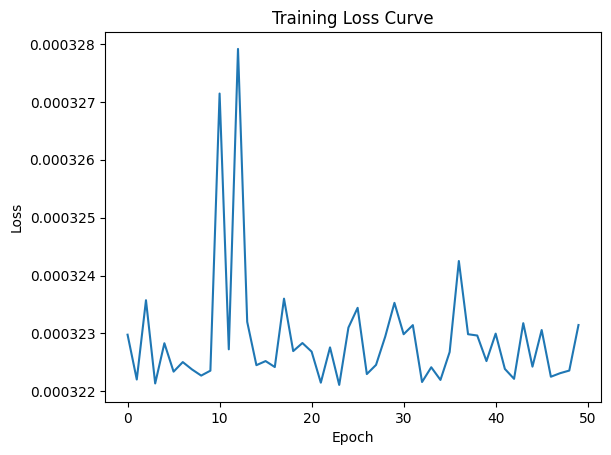

In [23]:
plt.plot(loss_values)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()


Deneme: lr=0.0005
Epoch 1, Avg Loss: 0.2673
Epoch 2, Avg Loss: 0.0190
Epoch 3, Avg Loss: 0.0029
Epoch 4, Avg Loss: 0.0012
Epoch 5, Avg Loss: 0.0007
Epoch 6, Avg Loss: 0.0007
Epoch 7, Avg Loss: 0.0006
Epoch 8, Avg Loss: 0.0006
Epoch 9, Avg Loss: 0.0006
Epoch 10, Avg Loss: 0.0006
Epoch 11, Avg Loss: 0.0006
Epoch 12, Avg Loss: 0.0006
Epoch 13, Avg Loss: 0.0006
Epoch 14, Avg Loss: 0.0006
Epoch 15, Avg Loss: 0.0006
Epoch 16, Avg Loss: 0.0005
Epoch 17, Avg Loss: 0.0006
Epoch 18, Avg Loss: 0.0005
Epoch 19, Avg Loss: 0.0005
Epoch 20, Avg Loss: 0.0005

Deneme: lr=0.001
Epoch 1, Avg Loss: 0.1516
Epoch 2, Avg Loss: 0.0011
Epoch 3, Avg Loss: 0.0006
Epoch 4, Avg Loss: 0.0006
Epoch 5, Avg Loss: 0.0005
Epoch 6, Avg Loss: 0.0006
Epoch 7, Avg Loss: 0.0005
Epoch 8, Avg Loss: 0.0006
Epoch 9, Avg Loss: 0.0005
Epoch 10, Avg Loss: 0.0005
Epoch 11, Avg Loss: 0.0005
Epoch 12, Avg Loss: 0.0005
Epoch 13, Avg Loss: 0.0005
Epoch 14, Avg Loss: 0.0005
Epoch 15, Avg Loss: 0.0005
Epoch 16, Avg Loss: 0.0005
Epoch 17,

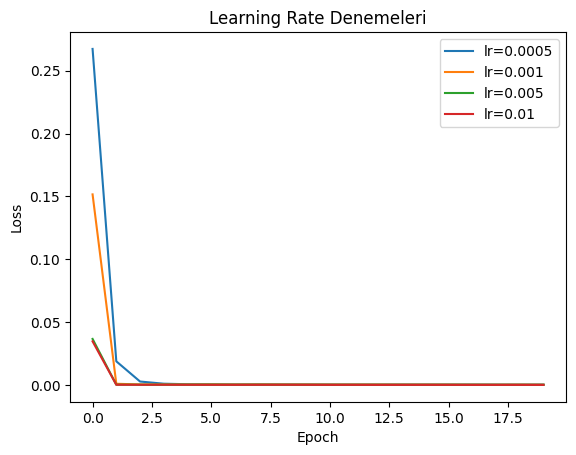

In [24]:
for lr in [0.0005, 0.001, 0.005, 0.01]:
    print(f"\nDeneme: lr={lr}")
    model = LSTMModel()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_values = []
    for epoch in range(20):
        total_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        loss_values.append(avg_loss)
        print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")
    plt.plot(loss_values, label=f"lr={lr}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Rate Denemeleri")
plt.legend()
plt.show()

In [25]:
torch.save(model.state_dict(), "lstm_model_day20.pth")

In [28]:
train_size = int(len(X_tensor) * 0.8)

X_train = X_tensor[:train_size]
X_test  = X_tensor[train_size:]

y_train = y_tensor[:train_size]
y_test  = y_tensor[train_size:]

In [29]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [30]:
num_epochs = 100
train_losses = []

for epoch in range(num_epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

print("LSTM Tam Eğitim Bitti")

Epoch 1, Avg Loss: 0.0992
Epoch 2, Avg Loss: 0.0059
Epoch 3, Avg Loss: 0.0012
Epoch 4, Avg Loss: 0.0008
Epoch 5, Avg Loss: 0.0006
Epoch 6, Avg Loss: 0.0004
Epoch 7, Avg Loss: 0.0003
Epoch 8, Avg Loss: 0.0003
Epoch 9, Avg Loss: 0.0003
Epoch 10, Avg Loss: 0.0003
Epoch 11, Avg Loss: 0.0003
Epoch 12, Avg Loss: 0.0003
Epoch 13, Avg Loss: 0.0003
Epoch 14, Avg Loss: 0.0003
Epoch 15, Avg Loss: 0.0002
Epoch 16, Avg Loss: 0.0003
Epoch 17, Avg Loss: 0.0002
Epoch 18, Avg Loss: 0.0002
Epoch 19, Avg Loss: 0.0002
Epoch 20, Avg Loss: 0.0002
Epoch 21, Avg Loss: 0.0002
Epoch 22, Avg Loss: 0.0002
Epoch 23, Avg Loss: 0.0002
Epoch 24, Avg Loss: 0.0002
Epoch 25, Avg Loss: 0.0002
Epoch 26, Avg Loss: 0.0002
Epoch 27, Avg Loss: 0.0002
Epoch 28, Avg Loss: 0.0002
Epoch 29, Avg Loss: 0.0002
Epoch 30, Avg Loss: 0.0002
Epoch 31, Avg Loss: 0.0002
Epoch 32, Avg Loss: 0.0002
Epoch 33, Avg Loss: 0.0002
Epoch 34, Avg Loss: 0.0002
Epoch 35, Avg Loss: 0.0002
Epoch 36, Avg Loss: 0.0002
Epoch 37, Avg Loss: 0.0002
Epoch 38, 

In [31]:
gru_model = GRUModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(gru_model.parameters(), lr=0.001)

num_epochs = 100
gru_train_losses = []

for epoch in range(num_epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = gru_model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    gru_train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

print("GRU Tam Eğitim Bitti")

Epoch 1, Avg Loss: 0.0921
Epoch 2, Avg Loss: 0.0045
Epoch 3, Avg Loss: 0.0002
Epoch 4, Avg Loss: 0.0002
Epoch 5, Avg Loss: 0.0002
Epoch 6, Avg Loss: 0.0002
Epoch 7, Avg Loss: 0.0002
Epoch 8, Avg Loss: 0.0002
Epoch 9, Avg Loss: 0.0002
Epoch 10, Avg Loss: 0.0001
Epoch 11, Avg Loss: 0.0001
Epoch 12, Avg Loss: 0.0001
Epoch 13, Avg Loss: 0.0001
Epoch 14, Avg Loss: 0.0001
Epoch 15, Avg Loss: 0.0001
Epoch 16, Avg Loss: 0.0001
Epoch 17, Avg Loss: 0.0001
Epoch 18, Avg Loss: 0.0001
Epoch 19, Avg Loss: 0.0001
Epoch 20, Avg Loss: 0.0001
Epoch 21, Avg Loss: 0.0001
Epoch 22, Avg Loss: 0.0001
Epoch 23, Avg Loss: 0.0001
Epoch 24, Avg Loss: 0.0001
Epoch 25, Avg Loss: 0.0001
Epoch 26, Avg Loss: 0.0001
Epoch 27, Avg Loss: 0.0001
Epoch 28, Avg Loss: 0.0001
Epoch 29, Avg Loss: 0.0001
Epoch 30, Avg Loss: 0.0001
Epoch 31, Avg Loss: 0.0001
Epoch 32, Avg Loss: 0.0001
Epoch 33, Avg Loss: 0.0001
Epoch 34, Avg Loss: 0.0001
Epoch 35, Avg Loss: 0.0001
Epoch 36, Avg Loss: 0.0001
Epoch 37, Avg Loss: 0.0001
Epoch 38, 

In [35]:
import time

model = LSTMModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
start = time.time()

for epoch in range(num_epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

end = time.time()
print("LSTM Training süresi:", end - start, "saniye")

Epoch 1, Avg Loss: 0.1130
Epoch 2, Avg Loss: 0.0099
Epoch 3, Avg Loss: 0.0016
Epoch 4, Avg Loss: 0.0011
Epoch 5, Avg Loss: 0.0007
Epoch 6, Avg Loss: 0.0004
Epoch 7, Avg Loss: 0.0003
Epoch 8, Avg Loss: 0.0003
Epoch 9, Avg Loss: 0.0003
Epoch 10, Avg Loss: 0.0003
Epoch 11, Avg Loss: 0.0003
Epoch 12, Avg Loss: 0.0003
Epoch 13, Avg Loss: 0.0003
Epoch 14, Avg Loss: 0.0002
Epoch 15, Avg Loss: 0.0002
Epoch 16, Avg Loss: 0.0002
Epoch 17, Avg Loss: 0.0002
Epoch 18, Avg Loss: 0.0002
Epoch 19, Avg Loss: 0.0002
Epoch 20, Avg Loss: 0.0003
Epoch 21, Avg Loss: 0.0002
Epoch 22, Avg Loss: 0.0002
Epoch 23, Avg Loss: 0.0002
Epoch 24, Avg Loss: 0.0002
Epoch 25, Avg Loss: 0.0002
Epoch 26, Avg Loss: 0.0002
Epoch 27, Avg Loss: 0.0002
Epoch 28, Avg Loss: 0.0002
Epoch 29, Avg Loss: 0.0002
Epoch 30, Avg Loss: 0.0002
Epoch 31, Avg Loss: 0.0002
Epoch 32, Avg Loss: 0.0002
Epoch 33, Avg Loss: 0.0002
Epoch 34, Avg Loss: 0.0002
Epoch 35, Avg Loss: 0.0002
Epoch 36, Avg Loss: 0.0002
Epoch 37, Avg Loss: 0.0002
Epoch 38, 

In [36]:
import time

gru_model = GRUModel()
criterion = nn.MSELoss()
optimizer = optim.Adam(gru_model.parameters(), lr=0.001)

num_epochs = 100
start = time.time()

for epoch in range(num_epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = gru_model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}, Avg Loss: {avg_loss:.4f}")

end = time.time()
print("GRU Training süresi:", end - start, "saniye")

Epoch 1, Avg Loss: 0.0655
Epoch 2, Avg Loss: 0.0073
Epoch 3, Avg Loss: 0.0002
Epoch 4, Avg Loss: 0.0002
Epoch 5, Avg Loss: 0.0002
Epoch 6, Avg Loss: 0.0002
Epoch 7, Avg Loss: 0.0002
Epoch 8, Avg Loss: 0.0002
Epoch 9, Avg Loss: 0.0002
Epoch 10, Avg Loss: 0.0001
Epoch 11, Avg Loss: 0.0001
Epoch 12, Avg Loss: 0.0001
Epoch 13, Avg Loss: 0.0001
Epoch 14, Avg Loss: 0.0001
Epoch 15, Avg Loss: 0.0001
Epoch 16, Avg Loss: 0.0001
Epoch 17, Avg Loss: 0.0001
Epoch 18, Avg Loss: 0.0001
Epoch 19, Avg Loss: 0.0001
Epoch 20, Avg Loss: 0.0001
Epoch 21, Avg Loss: 0.0001
Epoch 22, Avg Loss: 0.0001
Epoch 23, Avg Loss: 0.0001
Epoch 24, Avg Loss: 0.0001
Epoch 25, Avg Loss: 0.0001
Epoch 26, Avg Loss: 0.0001
Epoch 27, Avg Loss: 0.0001
Epoch 28, Avg Loss: 0.0001
Epoch 29, Avg Loss: 0.0001
Epoch 30, Avg Loss: 0.0001
Epoch 31, Avg Loss: 0.0001
Epoch 32, Avg Loss: 0.0001
Epoch 33, Avg Loss: 0.0001
Epoch 34, Avg Loss: 0.0001
Epoch 35, Avg Loss: 0.0001
Epoch 36, Avg Loss: 0.0001
Epoch 37, Avg Loss: 0.0001
Epoch 38, 

In [59]:
train_losses = []
test_losses = []
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

In [60]:
model.eval()
total_test_loss = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        output = model(X_batch)
        loss = criterion(output, y_batch)
        total_test_loss += loss.item()
avg_test_loss = total_test_loss / len(test_loader)
test_losses.append(avg_test_loss)

In [61]:
train_losses.append(avg_train_loss)
test_losses.append(avg_test_loss)

print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")

Epoch 100, Train Loss: 0.0001, Test Loss: 0.0029


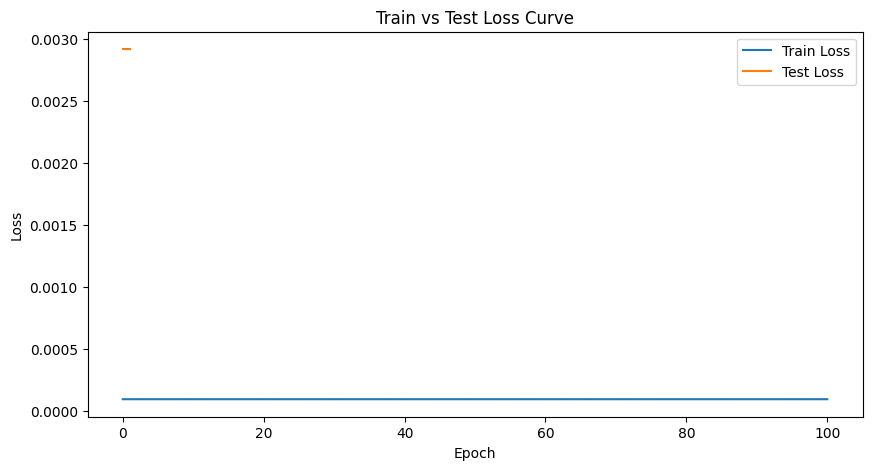

In [62]:
plt.figure(figsize=(10,5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Test Loss Curve")
plt.legend()
plt.show()

In [48]:
print("Train Loss uzunluğu:", len(train_losses))
print("Test Loss uzunluğu:", len(test_losses))
print("Train Loss örnekleri:", train_losses[:5])
print("Test Loss örnekleri:", test_losses[:5])

Train Loss uzunluğu: 1
Test Loss uzunluğu: 1
Train Loss örnekleri: [9.258598217760057e-05]
Test Loss örnekleri: [0.0029202397257138634]


In [63]:
model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_preds = model(X_test).numpy()
    gru_preds = gru_model(X_test).numpy()

lstm_pred_prices = scaler.inverse_transform(lstm_preds)
gru_pred_prices  = scaler.inverse_transform(gru_preds)
actual_prices    = scaler.inverse_transform(y_test.numpy())

In [64]:
from sklearn.metrics import mean_squared_error

mse_lstm = mean_squared_error(actual_prices, lstm_pred_prices)
mse_gru  = mean_squared_error(actual_prices, gru_pred_prices)

print("LSTM MSE:", mse_lstm)
print("GRU MSE:", mse_gru)

LSTM MSE: 930.3779296875
GRU MSE: 523.5541381835938


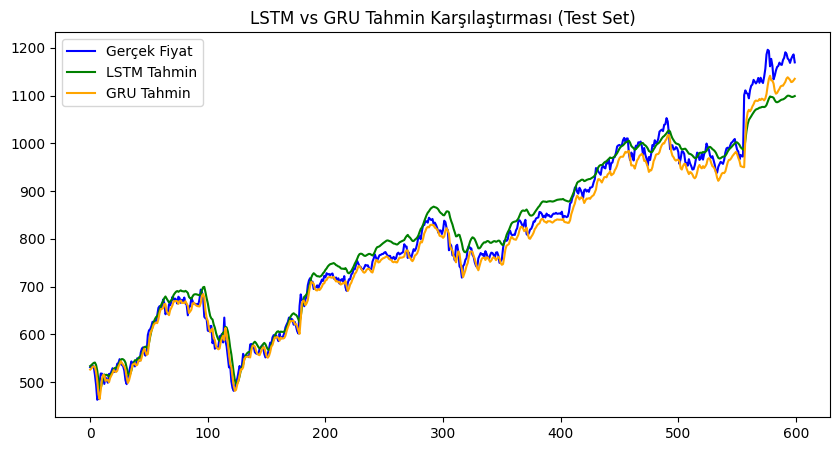

In [65]:
plt.figure(figsize=(10,5))
plt.plot(actual_prices, label="Gerçek Fiyat", color="blue")
plt.plot(lstm_pred_prices, label="LSTM Tahmin", color="green")
plt.plot(gru_pred_prices, label="GRU Tahmin", color="orange")
plt.legend()
plt.title("LSTM vs GRU Tahmin Karşılaştırması (Test Set)")
plt.show()